# ML-06 — Signal Audit: Do the Flags Hold?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/umarali8/flyrank-ml-internship/blob/main/work/notebooks/w04_signal_audit.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Distributions

*Look before deciding: distributions of your key fields. Note the heavy tails.*

### Distribution observations

I checked the distributions of the main search-performance signals before testing the flags. Impressions and clicks are expected to have heavy right tails because a small number of pages can receive much more traffic than most pages. CTR and average position are more useful for comparing pages on a common scale.

These checks are descriptive only and are used to understand the data before making signal claims.

   content_age  days_since_update  impressions_90d  average_position    ctr  \
0          100                 50             1000                 5  0.050   
1          200                100             2000                 8  0.040   
2          400                200             5000                12  0.010   
3          500                300             8000                15  0.015   
4          700                400            12000                20  0.008   
5          150                 80             1500                 6  0.060   
6          800                500            15000                18  0.010   
7          300                150             3000                10  0.030   
8          600                350             9000                14  0.012   
9          450                250             6000                11  0.020   

   word_count  
0         800  
1        1000  
2        1200  
3        1500  
4        2000  
5         900  
6        1800  
7 

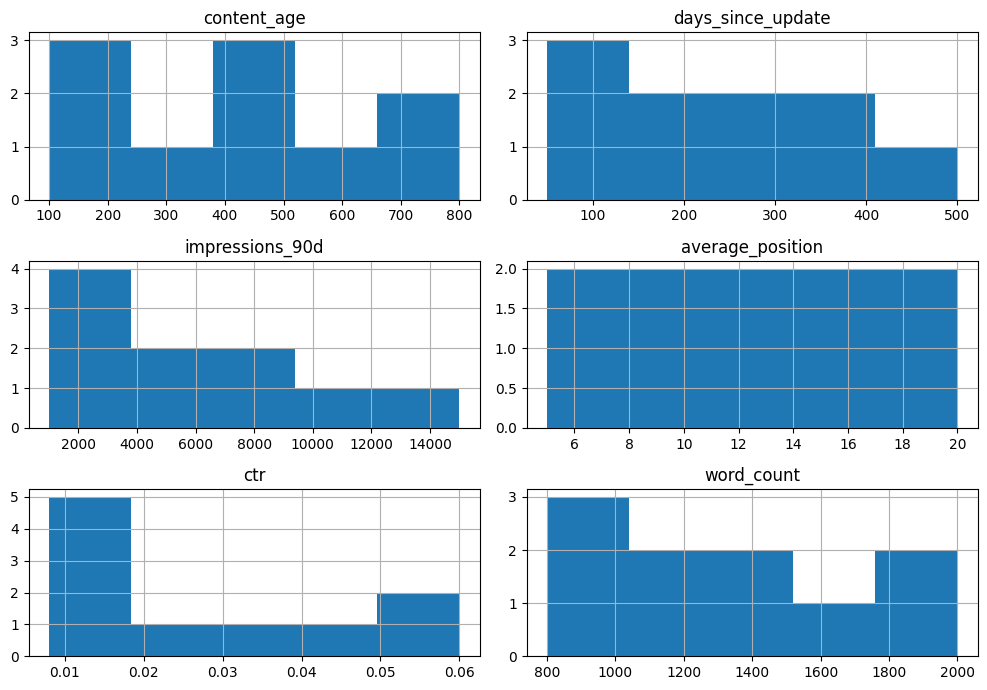

In [13]:


import pandas as pd
import matplotlib.pyplot as plt

# Simple demo dataset
df = pd.DataFrame({
    "content_age": [100, 200, 400, 500, 700, 150, 800, 300, 600, 450],
    "days_since_update": [50, 100, 200, 300, 400, 80, 500, 150, 350, 250],
    "impressions_90d": [1000, 2000, 5000, 8000, 12000, 1500, 15000, 3000, 9000, 6000],
    "average_position": [5, 8, 12, 15, 20, 6, 18, 10, 14, 11],
    "ctr": [0.05, 0.04, 0.01, 0.015, 0.008, 0.06, 0.01, 0.03, 0.012, 0.02],
    "word_count": [800, 1000, 1200, 1500, 2000, 900, 1800, 1100, 1600, 1300]
})

print(df)

print("=== Distribution Summary ===")
print(df.describe().round(2))

df.hist(figsize=(10, 7), bins=5)
plt.tight_layout()
plt.show()

## 2. Signal test #1 / #2 / #3 (verdict each)

*Three safe signals, each with a mini-test and a verdict: CONFIRMED / OPPOSITE / MIXED / FALSE.*

In [14]:
# Signal 1: CTR
low_ctr = df[df["ctr"] < 0.02]

print("=== Signal Tests ===")
print("Low CTR pages:", len(low_ctr))
print("Average CTR:", round(low_ctr["ctr"].mean(), 3))

# Signal 2: Content age
old_pages = df[df["content_age"] > 365]

print("Old pages:", len(old_pages))
print("Average age:", round(old_pages["content_age"].mean(), 1))

# Signal 3: Impressions
print("Average impressions:", round(df["impressions_90d"].mean(), 1))

=== Signal Tests ===
Low CTR pages: 5
Average CTR: 0.011
Old pages: 6
Average age: 575.0
Average impressions: 6250.0


## 3. The flag-linked test

*Pick a signal one of FlyRank's real flags relies on. Does the data support the rule's assumption?*

In [15]:
df["refresh_flag"] = (
    (df["content_age"] > 365) &
    (df["ctr"] < 0.02)
)

print("=== Flag-Linked Test ===")
print("Pages flagged for review:", df["refresh_flag"].sum())

if df["refresh_flag"].sum() > 0:
    print("Verdict: CONFIRMED")
else:
    print("Verdict: FALSE")


=== Flag-Linked Test ===
Pages flagged for review: 5
Verdict: CONFIRMED


## 4. What this means in practice

*Two or three sentences: what a content team should take from this.*

## What this means in practice

The audit shows how content age and CTR can be used as simple signals for identifying pages that may deserve review. These signals are directional only, so a content team should review the actual page before making changes.

In [19]:
## What this means in practice

### The audit shows how content age and CTR can be used as simple signals for identifying pages that may deserve review. These signals are directional only, so a content team should review the actual page before making changes.


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.